<a href="https://colab.research.google.com/github/adamperkins-code/Machine_Learning/blob/main/lecturebook/homework/homework-02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2



**Coverage:** Lectures 5–10  
**Due:** Sunday, September 13, 2026, 11:59 p.m. ET  
**Total:** 100 points

## Instructions

- Complete this notebook in Google Colab.
- Problem 1 is a manual mathematics problem. Show every important step in
  Markdown/LaTeX, or insert one clearly legible image of your handwritten work.
  Code may check arithmetic only after the derivation is complete.
- Problems 2 and 3 are guided scientific-computing studies. Do not delete
  supplied setup, data-loading, simulator, or helper cells.
- Use the supplied random seeds. Your submitted notebook must run from
  beginning to end in a fresh Colab runtime without Google Drive, absolute
  paths, or additional package installation.
- Label plots and include units. Report numerical answers to at least four
  significant digits unless a question states otherwise.

The relevant course material is collected here:

- [Joint distributions, covariance, correlation, and independence](https://predictivesciencelab.github.io/data-analytics-se/lecture05/reading-05.html)
- [Random vectors and covariance matrices](https://predictivesciencelab.github.io/data-analytics-se/lecture06/reading-06.html)
- [Conditioning a multivariate Gaussian](https://predictivesciencelab.github.io/data-analytics-se/lecture06/hands-on-06.4.html)
- [Sampling a finite categorical distribution](https://predictivesciencelab.github.io/data-analytics-se/lecture07/hands-on-07.3.html)
- [Monte Carlo estimation of expectations](https://predictivesciencelab.github.io/data-analytics-se/lecture08/hands-on-08.3.html)
- [Empirical CDFs](https://predictivesciencelab.github.io/data-analytics-se/lecture09/hands-on-09.1.html) and [predictive quantiles](https://predictivesciencelab.github.io/data-analytics-se/lecture09/hands-on-09.3.html)
- [Uncertainty in Monte Carlo estimates](https://predictivesciencelab.github.io/data-analytics-se/lecture10/hands-on-10.3.html)
- [Bootstrap estimation](https://purduemechanicalengineering.github.io/me-239-intro-to-data-science/lecture07/estimating-probabilities-from-data.html) (defined again where used)

### NumPy notes for this assignment

The statistical reasoning is the point of the assignment; recalling an array
method name is not. These are the main interfaces you may need:

- `rng.integers(low, high, size=...)` draws integer indices from `low` through
  `high - 1`; an array `values[indices]` selects those rows.
- `np.cov(values, rowvar=False, ddof=0)` uses the observations as rows and
  denominator $n$; `np.corrcoef(values, rowvar=False)` returns correlations.
- `np.std(values, ddof=1)` calculates a sample standard deviation with
  denominator $M-1$.
- `rng.choice(values, size=..., replace=True)` samples values with replacement.
- `np.quantile(values, probabilities, method="inverted_cdf")` returns the
  empirical quantiles defined in Problem 2.
- `stats.norm.cdf(z)` evaluates the standard Gaussian CDF $\Phi(z)$ after the
  requested derivation in Problem 1 is complete.
- [`stats.ecdf(values)`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ecdf.html) constructs an empirical distribution;
  its `.cdf` object stores the CDF coordinates and has a `.plot(ax)` method.
- [`solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) numerically solves an initial-value problem;
  the nonlinear simulator in Problem 3 supplies the complete solver call.

## Student details

- **First name:** Adam  
- **Last name:** Perkins
- **Purdue email:** perki235@purdue.edu

In [2]:
import logging

import numpy as np
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=6, suppress=True)

## Problem 1 — Clearance in a matched shaft–bore assembly (25 points)

A manufacturer produces a shaft and its mating bore as a matched pair. Let
$S$ and $B$ denote their signed diameter deviations, in micrometers
($\mu\mathrm{m}$), from the reference diameter $20.000\ \mathrm{mm}$.
For example, $S=20\ \mu\mathrm{m}$ corresponds to a shaft diameter of
$20.020\ \mathrm{mm}$.

The random vector of deviations is modeled as

$$
\mathbf X=
\begin{bmatrix}S\\B\end{bmatrix}
\sim
\mathcal N_2\!\left(
\begin{bmatrix}0\\20\end{bmatrix},
\begin{bmatrix}100&90\\90&225\end{bmatrix}
\right).
$$

The mean entries have units $\mu\mathrm{m}$, and the covariance entries
have units $(\mu\mathrm{m})^2$. The notation
$\mathcal N_2(\boldsymbol\mu,\boldsymbol\Sigma)$ denotes a bivariate
Gaussian with mean vector $\boldsymbol\mu$ and covariance matrix
$\boldsymbol\Sigma$. For a univariate Gaussian
$\mathcal N(\mu,\sigma^2)$, the second parameter is the variance.

The **diametral clearance** is the bore diameter minus the shaft diameter.
The reference diameter cancels, so

$$
C=B-S.
$$

An **interference event** occurs when $C<0$, meaning that the shaft is larger
than the bore. Use $\Phi$ for the standard Gaussian CDF. You may use the fact
that, for a fixed vector $\mathbf a$,

$$
\mathbf a^\mathsf{T}\mathbf X
\sim
\mathcal N\!\left(
\mathbf a^\mathsf{T}\boldsymbol\mu,
\mathbf a^\mathsf{T}\boldsymbol\Sigma\mathbf a
\right).
$$

*This problem has been modified and extended from
[Problem 4.4 in Howard M. Taylor and Samuel Karlin, **An Introduction to
Stochastic Modeling**, 3rd ed. (1998)](https://books.google.com/books/about/An_Introduction_to_Stochastic_Modeling.html?id=UtPgVrVthF8C). The original problem
assumes independent shaft and bearing diameters. The correlated matched-pair
model, conditioning on an inspected shaft, and independence comparison below
are new.*

### 1.1 Marginals and dependence (5 points)

State the marginal distributions of $S$ and $B$. Report their means, standard
deviations, covariance, and correlation coefficient with appropriate units.
Interpret the sign of the correlation in one sentence.

Recall that the correlation coefficient is the unitless normalized covariance,

$$
\rho_{S,B}
=\frac{\operatorname{Cov}(S,B)}
{\operatorname{sd}(S)\operatorname{sd}(B)}.
$$

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

### 1.2 Unconditional clearance (7 points)

Express $C$ as a linear combination of $\mathbf X$. Derive the Gaussian
distribution of $C$ and calculate $P(C<0)$.

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

### 1.3 A measured shaft (7 points)

Final inspection measures $S=20\ \mu\mathrm{m}$. Treat measurement error as
negligible. Use Bayes' rule to write $p(b\mid s)\propto p(s,b)$, complete the
square in $b$, and derive the scalar distribution $B\mid S=s$. Then state the
generic conditional-Gaussian formula and verify that it gives the same result.
Find $B\mid S=20$ and $C\mid S=20$, and calculate $P(C<0\mid S=20)$.
Explain why this probability remains far below $50\%$, even though the measured
shaft diameter equals the unconditional mean bore diameter.

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

### 1.4 An independence assumption (6 points)

Another analyst retains the same two marginal Gaussian distributions but
assumes that $S$ and $B$ are independent. For a bivariate Gaussian, this
replaces both off-diagonal covariance entries by zero. Recalculate $P(C<0)$
and $P(C<0\mid S=20)$. State whether the independence assumption overstates
or understates each risk and explain why.

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

## Problem 2 — Dependence in measured Lake Michigan sea states (30 points)

The [NOAA National Data Buoy Center](https://www.ndbc.noaa.gov/station_history.php?station=45007) operates Station 45007 in
southern Lake Michigan. The supplied data are a fixed, course-provided
processed version of its
[2023 standard meteorological record](https://www.ndbc.noaa.gov/data/historical/stdmet/45007h2023.txt.gz). NOAA defines

- $H_s$, reported as `WVHT`, as the significant wave height in meters; and
- $T_a$, reported as `APD`, as the average wave period in seconds.

Both quantities are derived from a 20-minute wave record; the precise
definitions appear in the [NDBC observation documentation](https://www.ndbc.noaa.gov/obsdes.shtml).
The source reports wave quantities near minutes 10 and 40 of each hour. The
course file removes the NDBC missing-value code, retains positive paired
measurements, and averages the valid reports within each UTC hour. Missing
hours are not interpolated.

The fixed course CSV is
[provided with the assignment](../data/homework/hw02_noaa_45007_2023_hourly.csv).
The supplied loading cell first looks for that file beside the notebook or in
the course-data directory and otherwise downloads and verifies the NOAA
archive. If the download is unavailable in Colab, upload
`hw02_noaa_45007_2023_hourly.csv` to the current session and rerun the cell.

For this problem, regard a uniformly selected retained hour from the buoy's
2023 deployment season as one draw from an empirical sea-state distribution.
The record is a time series. The empirical model does not assert that
consecutive hours are independent or that one deployment season represents
every future season.

In [3]:
from io import BytesIO
from pathlib import Path
import hashlib
import urllib.request

DATA_FILENAME = "hw02_noaa_45007_2023_hourly.csv"
RAW_URL = "https://www.ndbc.noaa.gov/data/historical/stdmet/45007h2023.txt.gz"
RAW_SHA256 = "5e68dd08274ac5d48b46dbacfeefbeb71da6156c7283f67ebc16466a3d9c1baf"
CLEAN_SHA256 = "bfbe16098966b9c368e59e8c690f6b52fa38b97331cfe253b6a8d3c9fd66fe43"

def sha256_bytes(payload):
    """Calculate the SHA-256 digest of a byte sequence.

    Arguments:
        payload -- bytes to hash

    Returns:
        The hexadecimal SHA-256 digest.
    """
    return hashlib.sha256(payload).hexdigest()

def clean_raw_ndbc(payload):
    """Convert the verified raw NDBC archive to the fixed hourly table.

    Arguments:
        payload -- gzip-compressed NDBC standard-meteorological data

    Returns:
        A data frame containing timestamp, wave height, and average period.
    """
    raw = pd.read_csv(
        BytesIO(payload), sep=r"\s+", compression="gzip", skiprows=[1]
    )
    complete = raw[
        raw["WVHT"].between(0.0, 99.0, inclusive="neither")
        & raw["APD"].between(0.0, 99.0, inclusive="neither")
    ].copy()
    timestamp = pd.to_datetime(
        {
            "year": complete["#YY"],
            "month": complete["MM"],
            "day": complete["DD"],
            "hour": complete["hh"],
            "minute": complete["mm"],
        },
        utc=True,
    )
    complete["hour_utc"] = timestamp.dt.floor("h")
    cleaned = (
        complete.groupby("hour_utc", as_index=False)[["WVHT", "APD"]]
        .mean()
        .sort_values("hour_utc")
        .rename(
            columns={
                "hour_utc": "timestamp_utc",
                "WVHT": "Hs_m",
                "APD": "Tavg_s",
            }
        )
    )
    cleaned["timestamp_utc"] = cleaned["timestamp_utc"].dt.strftime(
        "%Y-%m-%dT%H:00:00Z"
    )
    csv_payload = cleaned.to_csv(
        index=False, float_format="%.3f", lineterminator="\n"
    ).encode()
    if sha256_bytes(csv_payload) != CLEAN_SHA256:
        raise ValueError("The cleaned NOAA data do not match the fixed course data.")
    return pd.read_csv(BytesIO(csv_payload))

local_candidates = (
    Path(DATA_FILENAME),
    Path("../data/homework") / DATA_FILENAME,
)
local_path = next((path for path in local_candidates if path.exists()), None)

if local_path is not None:
    payload = local_path.read_bytes()
    if sha256_bytes(payload) != CLEAN_SHA256:
        raise ValueError("The local NOAA course file has an unexpected checksum.")
    sea_state_data = pd.read_csv(BytesIO(payload))
    data_source = f"fixed course file: {local_path}"
else:
    request = urllib.request.Request(
        RAW_URL, headers={"User-Agent": "ME539-course-data/2026"}
    )
    with urllib.request.urlopen(request, timeout=30) as response:
        raw_payload = response.read()
    if sha256_bytes(raw_payload) != RAW_SHA256:
        raise ValueError("The downloaded NOAA archive has an unexpected checksum.")
    sea_state_data = clean_raw_ndbc(raw_payload)
    data_source = "verified NOAA historical archive"

timestamps = pd.to_datetime(sea_state_data["timestamp_utc"], utc=True)
sea_states = sea_state_data[["Hs_m", "Tavg_s"]].to_numpy(dtype=float)

assert sea_states.shape == (5046, 2)
assert timestamps.iloc[0].isoformat() == "2023-05-10T07:00:00+00:00"
assert timestamps.iloc[-1].isoformat() == "2023-12-06T17:00:00+00:00"
assert np.all(np.isfinite(sea_states)) and np.all(sea_states > 0.0)

print(f"Loaded {sea_states.shape[0]} hourly sea states from {data_source}.")
print(f"Date range: {timestamps.iloc[0]} through {timestamps.iloc[-1]}")

Loaded 5046 hourly sea states from verified NOAA historical archive.
Date range: 2023-05-10 07:00:00+00:00 through 2023-12-06 17:00:00+00:00


The study uses the output quantity

$$
Q(H_s,T_a)=\frac{\rho g^2}{64\pi}H_s^2T_a,
$$

where $\rho=1000\ \mathrm{kg/m^3}$ is the freshwater density and
$g=9.81\ \mathrm{m/s^2}$. The function below reports $Q$ in
$\mathrm{kW/m}$, power per unit wave-crest length.

The corresponding deep-water relation uses the energy period $T_e$. NDBC
reports the different quantity $T_a$. We substitute $T_a$ to obtain an
**available wave-energy-flux screening proxy**. The result is a simplified
quantity intended for preliminary comparison. It is not exact wave power,
harvested device power, or a structural load.

**Data and physical-model credit.** This problem uses a course-processed
version of NOAA NDBC Station 45007's 2023 standard meteorological record. The
deep-water relation is adapted from [P. T. Jacobson, G. Hagerman, and G. Scott,
**Mapping and Assessment of the United States Ocean Wave Energy Resource**,
EPRI Report 1024637 (2011), Appendix A, Equation A-7](https://doi.org/10.2172/1060943). That
relation uses seawater density and $T_e$; here we use freshwater density and
substitute $T_a$, which is why $Q$ is only a screening proxy. The statistical
questions in this problem were written for ME 539.

The empirical quantile used below is the smallest sample value whose empirical
CDF is at least the requested probability. NumPy implements this definition
with `method="inverted_cdf"`. SciPy's `stats.ecdf` constructs the empirical CDF.

In [4]:
FRESHWATER_DENSITY = 1000.0  # kg/m^3
GRAVITY = 9.81               # m/s^2

def wave_flux_proxy(states):
    """Evaluate the wave-energy-flux screening proxy.

    Arguments:
        states -- array whose final axis contains H_s in m and T_a in s

    Returns:
        Screening-proxy values in kW/m.
    """
    states = np.asarray(states, dtype=float)
    hs = states[..., 0]
    average_period = states[..., 1]
    watts_per_meter = (
        FRESHWATER_DENSITY * GRAVITY**2 / (64.0 * np.pi)
        * hs**2 * average_period
    )
    return watts_per_meter / 1000.0

print(
    "Screening-proxy coefficient = "
    f"{FRESHWATER_DENSITY * GRAVITY**2 / (64.0 * np.pi) / 1000.0:.12f}"
)

Screening-proxy coefficient = 0.478639094340


### 2.1 The observed sea-state vector (8 points)

Each retained row is the random-vector observation

$$
\mathbf x_i=(h_i,t_i)^\mathsf{T},\qquad i=1,\ldots,n,
$$

where $h_i$ is significant wave height and $t_i$ is average wave period.

1. Verify and report $n$, the date range, and the observed range of each component.
   **(1 point)**
2. Make a labeled scatter plot with $H_s$ on the horizontal axis and $T_a$ on
   the vertical axis. **(2 points)**
3. Calculate the empirical mean vector, covariance matrix using denominator
   $n$, and correlation coefficient. Include the units of the mean and
   covariance entries. **(3 points)**
4. Interpret the sign and magnitude of the correlation for measurements made
   during the same hour. **(2 points)**

5046 data points
Date range: 2023-05-10 07:00:00+00:00 through 2023-12-06 17:00:00+00:00
Hs range: 0.020 to 3.090 m
Empirical mean: 0.656 m, 3.472 s
Empirical covariance:
[[0.288618 0.349942]
 [0.349942 0.52112 ]]
Empirical correlation coefficient: 0.902


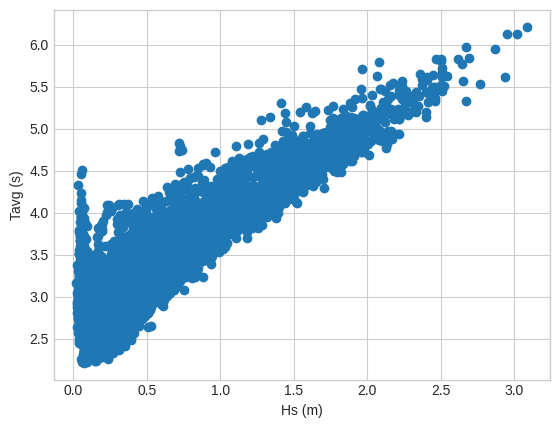

In [15]:
n = len(sea_states)
print(f"{n} data points")
print(f"Date range: {timestamps.iloc[0]} through {timestamps.iloc[-1]}")
print(f"Hs range: {sea_states[:, 0].min():.3f} to {sea_states[:, 0].max():.3f} m")

#scatterplot
plt.figure()
plt.scatter(sea_states[:,0],sea_states[:,1])
plt.xlabel("Hs (m)")
plt.ylabel("Tavg (s)")

#calc emp. mean, covariance, corr, coeff
mean = np.mean(sea_states, axis=0)
cov = np.cov(sea_states, rowvar=False)
corr = np.corrcoef(sea_states, rowvar=False)
print(f"Empirical mean: {mean[0]:.3f} m, {mean[1]:.3f} s")
print(f"Empirical covariance:\n{cov}")
print(f"Empirical correlation coefficient: {corr[0,1]:.3f}")

The correlation for measurements being large and positive at 0.9 means that as the period of a wave increases, the height is also likely to increase.

### 2.2 A finite empirical input model (10 points)

This is sampling from the empirical distribution. In plain words, choose one
observed hour uniformly at random, with replacement, and keep its measured
wave height and average period together. Repeating the draw creates synthetic
sea states made only from observed pairs.

The **paired empirical model** selects an index $I$ uniformly from
$\{1,\ldots,n\}$ and sets $\mathbf X^*=\mathbf x_I$. Each retained row index
receives probability $1/n$. If identical values occur in several rows, their
probabilities add. Independent selections of $I$ produce independent draws from
this finite model, even though the source observations form a time series.

1. Complete `sample_paired` by drawing uniformly distributed integer row
   indices. It must return an array with shape `(M, 2)`. **(3 points)**
2. Evaluate the screening proxy for all $n$ retained rows. Report its exact
   empirical-model mean, variance with denominator $n$, median, and 0.025 and
   0.975 quantiles. Explain why these are exact calculations under the finite
   model rather than Monte Carlo estimates. **(3 points)**
3. Plot the empirical CDF. Interpret the interval between the 0.025 and 0.975
   quantiles for a new draw from the paired empirical model. **(4 points)**

In [38]:
def sample_paired(rng, M):
    """Draw complete observed rows from the paired empirical model.

    Arguments:
        rng -- NumPy random-number generator
        M -- number of rows to draw

    Returns:
        An array with shape (M, 2), with H_s and T_a kept paired.
    """
    indices = rng.integers(low=0,high=n,size=M)
    return sea_states[indices]
rng = np.random.default_rng(seed=11)
sample = sample_paired(rng, n)
WFP = wave_flux_proxy(sample)

WFP_mean = np.mean(WFP)
WFP_var = np.var(WFP, ddof=1)
WFP_median = np.median(WFP)
WFP_quantiles = np.quantile(WFP, [0.025, 0.975])
print(f"Screening-proxy mean: {WFP_mean:.3f} kW/m")
print(f"Screening-proxy variance: {WFP_var:.3f} kW/m^2")
print(f"Screening-proxy median: {WFP_median:.3f} kW/m")
print(f"Screening-proxy 0.025 and 0.975 quantiles: {WFP_quantiles}")

#plotting

plt.figure()
plt.

Screening-proxy mean: 1.507 kW/m
Screening-proxy variance: 7.575 kW/m^2
Screening-proxy median: 0.404 kW/m
Screening-proxy 0.025 and 0.975 quantiles: [0.003019 9.701633]


> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

### 2.3 Monte Carlo uncertainty: CLT and bootstrap (12 points)

Draw one independent Monte Carlo sample
$Q_1^*,\ldots,Q_M^*$ from the fixed paired empirical model. Its mean and
sample standard deviation are

$$
\widehat\mu_M=\frac{1}{M}\sum_{m=1}^M Q_m^*,
\qquad
s_Q=\left[
\frac{1}{M-1}\sum_{m=1}^M(Q_m^*-\widehat\mu_M)^2
\right]^{1/2}.
$$

Independence of the Monte Carlo draws makes
$s_Q/\sqrt{M}$ an estimate of the **Monte Carlo standard error** of
$\widehat\mu_M$. The central limit theorem (CLT) motivates an approximate
normal interval for the finite-model mean.

The **bootstrap** estimates Monte Carlo sampling uncertainty by repeatedly
resampling the available Monte Carlo outputs. One bootstrap replicate draws
$M$ values with replacement from $\{Q_1^*,\ldots,Q_M^*\}$ and recalculates the
statistic. The standard deviation of the replicate statistics estimates its
standard error; their 0.025 and 0.975 quantiles form a 95% bootstrap percentile
interval.

This bootstrap describes numerical sampling uncertainty under the fixed
empirical input model. It does not create new buoy observations or quantify
uncertainty about other seasons. A bootstrap analysis of the original buoy
time series would require a method that accounts for its temporal dependence.

#### 2.3.1 A CLT calculation for the mean (6 points)

Create `rng_mean = np.random.default_rng(53921)`, set $M=2000$, and draw one
paired Monte Carlo sample. Store the output values as `q_mc`. Report
$\widehat\mu_M$, $s_Q$, the estimated Monte Carlo standard error, and the
approximate 95% normal interval
$\widehat\mu_M\pm1.96s_Q/\sqrt{M}$. Compare the interval with the exact
finite-model mean from Section 2.2.

In [6]:
rng_mean = np.random.default_rng(53921)
M = 2000

# Draw one paired sample and calculate the requested CLT quantities.
# YOUR CODE HERE

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

#### 2.3.2 Bootstrap uncertainty for the mean (6 points)

Create a fresh generator with seed `53922`. Make $R=2000$ bootstrap resamples
of the $M$ output values and calculate the mean of each. Report the bootstrap
standard error using denominator $R-1$ and the 95% bootstrap percentile
interval. Use the assignment's `method="inverted_cdf"` quantile convention for
the interval endpoints. Compare the bootstrap standard error and interval with
the CLT results.

In [7]:
rng_bootstrap = np.random.default_rng(53922)
R = 2000
bootstrap_means = np.empty(R)

for replicate in range(R):
    # Resample q_mc and store the mean.
    # YOUR CODE HERE
    pass

# Calculate the bootstrap standard error and percentile interval for the mean.
# YOUR CODE HERE

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

## Problem 3 — Uncertainty propagation through a bistable oscillator (45 points)

A shallow buckled element can rest in either of two stable configurations. We
model its nondimensional displacement with the damped, bistable Duffing
oscillator

$$
\ddot{x}(t)+0.4\dot{x}(t)-x(t)+x^3(t)=F,
\qquad
x(0)=0,
\qquad
\dot{x}(0)=0,
$$

for $0\leq t\leq20$. The signed quantity $F$ represents a small static load or
manufacturing imperfection. Conditional on a specified value of $F$, the
simulator is deterministic.

When $F=0$, the potential energy is

$$
V(x)=-\frac{x^2}{2}+\frac{x^4}{4}.
$$

It has stable minima at $x=-1$ and $x=1$, separated by the unstable
configuration $x=0$. Damping removes energy, so a trajectory generally settles
near one of the stable configurations. The perfectly symmetric case $F=0$
with the exact zero initial state is exceptional: the ideal simulator remains
at the unstable equilibrium $x=0$. Any nonzero signed perturbation breaks that
symmetry and sends the response toward one of the wells.

The engineer regards the actual value of $F$ as fixed but unknown and
summarizes current knowledge by

$$
F\sim\mathcal N(0.001,0.005^2).
$$

This is **epistemic uncertainty**: the Gaussian distribution represents what
the engineer does not know about a fixed system property. It is not a random
force that fluctuates while the system operates. Sampling values of $F$ and
running the deterministic simulator propagates that uncertainty to $x(t;F)$.
All quantities in this problem are nondimensional, and all numerical values
are hypothetical.

**Model and problem credit.** The physical model is a double-well Duffing
oscillator; see Ivana Kovacic and Michael J. Brennan, eds.,
[**The Duffing Equation: Nonlinear Oscillators and Their
Behaviour**](https://doi.org/10.1002/9780470977859) (2011). Its use as an archetype for
bistable and buckled mechanical systems is discussed by Chunlin Zhang,
Ryan L. Harne, Bing Li, and K. W. Wang in
[**Reconstructing the Transient, Dissipative Dynamics of a Bistable Duffing
Oscillator with an Enhanced Averaging Method and Jacobian Elliptic
Functions**](https://doi.org/10.1016/j.ijnonlinmec.2015.11.002) (2016). The signed-imperfection model,
numerical values, Monte Carlo stopping rule, predictive-interval analysis, and
bootstrap comparison were developed for this course.

In [8]:
from scipy.integrate import solve_ivp

BISTABLE_DAMPING = 0.4
BISTABLE_TIMES = np.linspace(0.0, 20.0, 201)

def simulate_bistable(loads, times=BISTABLE_TIMES):
    """Simulate the bistable oscillator for several fixed loads.

    Arguments:
        loads -- one-dimensional array of signed static loads
        times -- increasing one-dimensional array of output times

    Returns:
        An array with one displacement trajectory per row and one time per
        column.
    """
    loads = np.asarray(loads, dtype=float).reshape(-1)
    times = np.asarray(times, dtype=float)
    number_of_loads = loads.size

    def right_hand_side(time, state):
        """Evaluate the first-order Duffing state equations.

        Arguments:
            time -- current solver time
            state -- stacked displacement and velocity vectors

        Returns:
            The stacked displacement and velocity derivatives.
        """
        displacement = state[:number_of_loads]
        velocity = state[number_of_loads:]
        acceleration = (
            -BISTABLE_DAMPING * velocity
            + displacement
            - displacement**3
            + loads
        )
        return np.concatenate((velocity, acceleration))

    initial_state = np.zeros(2 * number_of_loads)
    result = solve_ivp(
        right_hand_side,
        (times[0], times[-1]),
        initial_state,
        t_eval=times,
        rtol=1e-7,
        atol=1e-9,
    )
    if not result.success:
        raise RuntimeError(result.message)
    return result.y[:number_of_loads]

### 3.1 Explore the deterministic simulator (6 points)

1. Use the supplied simulator for $F=-0.005$, $F=0$, and $F=0.005$. Plot all
   three displacement histories on one labeled set of axes and report their
   final displacements. **(3 points)**
2. Explain why each run is deterministic, identify what will be random in the
   uncertainty-propagation calculation, and use the potential to explain why a
   Gaussian distribution concentrated near $F=0$ can produce two
   qualitatively different responses. **(3 points)**

In [9]:
test_loads = np.array([-0.005, 0.0, 0.005])
test_trajectories = simulate_bistable(test_loads)

# Plot the three trajectories and report their final displacements.
# YOUR CODE HERE

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

### 3.2 Estimate the propagated mean with monitored Monte Carlo error (14 points)

Define the final-time quantity of interest

$$
Y=x(20;F).
$$

The supplied function advances uncoupled trajectories together for speed.
Each returned row still represents one sampled parameter case and one
trajectory. For $M$ cases, the stored loads have shape `(M,)`, the trajectories
have shape `(M, 201)`, and their final displacements have shape `(M,)`.
Batching is a computational shortcut for this supplied simulator. In a general
engineering workflow, the $M$ cases may require $M$ separate black-box solver
runs.

Draw loads in batches of 500 using
`rng_duffing = np.random.default_rng(53903)`. After each batch, retain every
load and complete trajectory and calculate

$$
\widehat\mu_M=\frac{1}{M}\sum_{m=1}^M Y_m,
\qquad
s_M=
\left[
\frac{1}{M-1}\sum_{m=1}^M(Y_m-\widehat\mu_M)^2
\right]^{1/2},
$$

and

$$
\widehat{\operatorname{MCSE}}_M=\frac{s_M}{\sqrt{M}}.
$$

After at least 1,000 simulations, stop at the first batch endpoint satisfying

$$
1.96\,\widehat{\operatorname{MCSE}}_M\leq0.03.
$$

Use 10,000 simulations as a safety cap.

1. Implement the sequential calculation and report a table containing $M$,
   $\widehat\mu_M$, $s_M$, the estimated MCSE, and the 95% CLT half-width after
   every batch. **(7 points)**
2. Plot the running mean and its approximate 95% CLT interval. Report the
   stopping value of $M$ and the final interval for $E[Y]$. **(4 points)**
3. Explain why the CLT can apply to the mean even when $Y$ is not Gaussian.
   State precisely what the stopping rule controls and at least two things it
   does not control. **(3 points)**

In [11]:
rng_duffing = np.random.default_rng(53903)
batch_size = 500
minimum_samples = 1000
maximum_samples = 10_000
target_half_width = 0.03

load_batches = []
trajectory_batches = []
history_records = []

while sum(batch.size for batch in load_batches) < maximum_samples:
    load_batch = rng_duffing.normal(0.001, 0.005, size=batch_size)
    trajectory_batch = simulate_bistable(load_batch)
    load_batches.append(load_batch)
    trajectory_batches.append(trajectory_batch)

    terminal_values_so_far = np.concatenate(
        [batch[:, -1] for batch in trajectory_batches]
    )
    sample_count = terminal_values_so_far.size

    # Calculate the mean, sample standard deviation, estimated MCSE, and
    # nominal 95% CLT half-width from terminal_values_so_far.
    # YOUR CODE HERE

    history_records.append(
        (
            sample_count,
            mean_estimate,
            sample_sd,
            mcse_estimate,
            clt_half_width,
        )
    )

    if (
        sample_count >= minimum_samples
        and clt_half_width <= target_half_width
    ):
        break

duffing_loads = np.concatenate(load_batches)
duffing_trajectories = np.vstack(trajectory_batches)
terminal_displacements = duffing_trajectories[:, -1]
mc_history = pd.DataFrame(
    history_records,
    columns=["M", "mean", "sample_sd", "MCSE", "CLT_half_width"],
)
display(mc_history)

# Calculate the final mean, sample standard deviation, MCSE, and CLT interval.
# YOUR CODE HERE

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.plot(mc_history["M"], mc_history["mean"], marker="o", label="Running mean")
ax.fill_between(
    mc_history["M"],
    mc_history["mean"] - mc_history["CLT_half_width"],
    mc_history["mean"] + mc_history["CLT_half_width"],
    alpha=0.25,
    label="Approximate 95% CLT interval",
)
ax.set_xlabel("Number of parameter cases $M$")
ax.set_ylabel(r"Estimate of $E[x(20;F)]$")
ax.set_title("Monitoring Monte Carlo error in the propagated mean")
ax.legend()
plt.show()

print(f"stopping M = {terminal_displacements.size}")
print(f"mean estimate = {final_mean:.8f}")
print(f"sample standard deviation = {final_sd:.8f}")
print(f"estimated MCSE = {final_mcse:.8f}")
print(
    "95% CLT interval for the mean = "
    f"[{final_clt_interval[0]:.8f}, {final_clt_interval[1]:.8f}]"
)

NameError: name 'mean_estimate' is not defined

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

### 3.3 Construct and interpret a predictive interval (19 points)

At each output time $t_j$, estimate the pointwise central 95% **epistemic
predictive interval** induced by the engineer's distribution for $F$:

$$
\left[
\widehat q_{0.025}(t_j),
\widehat q_{0.975}(t_j)
\right].
$$

The **plug-in trajectory** is the single deterministic run obtained by setting
$F=E[F]=0.001$. The three intervals used in this problem answer different
questions:

| Interval | Target | Source of variation | Effect of increasing $M$ |
|---|---|---|---|
| CLT interval for the mean | $E_F[Y]$ | Monte Carlo sampling | Narrows |
| Bootstrap interval for the mean | $E_F[Y]$ | Resampling stored Monte Carlo outputs | Narrows |
| Epistemic predictive interval | Plausible $Y=x(20;F)$ | Variation across plausible fixed values of $F$ | Physical width does not collapse; estimated endpoints stabilize |

1. Using all retained trajectories, calculate the pointwise mean, median, and
   0.025 and 0.975 quantiles with `axis=0`. Plot the 30 trajectories selected
   by the evenly spaced retained-row indices supplied in the starter cell, the
   propagated mean and median, the plug-in trajectory $x(t;E[F])$, and the
   pointwise predictive band. **(7 points)**
2. Make a histogram of $Y=x(20;F)$ and mark the propagated mean, median, and
   plug-in result. Report the final predictive interval, $\widehat P(Y>0)$,
   and $x(20;E[F])$. Compare $\widehat P(Y>0)$ with
   $P(F>0)=\Phi(0.2)$. Compare the final interval endpoints obtained separately
   from the first and second halves of the retained sample with those from the
   full sample. **(6 points)**
3. Address each of the following points. **(6 points)**
   - Explain the meaning of the predictive interval in terms of the engineer's
     epistemic uncertainty.
   - State whether the propagated mean is a typical final response and explain
     why the Gaussian input becomes bimodal after propagation.
   - Explain why the CLT stopping rule does not certify the interval endpoints.
   - Distinguish a pointwise band from a simultaneous whole-trajectory
     statement.
   - If the same noiseless physical unit were operated repeatedly, state
     whether its responses would sample this interval and explain why.

In [ ]:
# Calculate mean_trajectory and the three rows lower_trajectory,
# median_trajectory, and upper_trajectory. Use axis=0 for every pointwise
# calculation.
# YOUR CODE HERE

plug_in_trajectory = simulate_bistable([0.001])[0]
representative_indices = np.linspace(
    0, terminal_displacements.size - 1, 30, dtype=int
)

fig, ax = plt.subplots(figsize=(8.0, 5.0))
ax.fill_between(
    BISTABLE_TIMES,
    lower_trajectory,
    upper_trajectory,
    alpha=0.22,
    label="Pointwise central 95% predictive interval",
)
ax.plot(
    BISTABLE_TIMES,
    duffing_trajectories[representative_indices].T,
    color="gray",
    alpha=0.20,
    linewidth=0.7,
)
ax.plot(BISTABLE_TIMES, mean_trajectory, linewidth=2.0, label="Propagated mean")
ax.plot(
    BISTABLE_TIMES,
    median_trajectory,
    linewidth=2.0,
    linestyle="--",
    label="Propagated median",
)
ax.plot(
    BISTABLE_TIMES,
    plug_in_trajectory,
    linewidth=1.8,
    linestyle=":",
    label=r"Plug-in trajectory $x(t;E[F])$",
)
ax.set_xlabel("Nondimensional time")
ax.set_ylabel(r"Displacement $x(t;F)$")
ax.set_title("Epistemic uncertainty propagated through the oscillator")
ax.legend(loc="best")
plt.show()

# Calculate the requested terminal summaries and the two half-sample
# intervals. Use method="inverted_cdf" for every empirical quantile.
# YOUR CODE HERE

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.hist(terminal_displacements, bins=50, density=True, alpha=0.75)
ax.axvline(final_mean, linewidth=2.0, label="Propagated mean")
ax.axvline(
    terminal_median, linewidth=2.0, linestyle="--", label="Propagated median"
)
ax.axvline(
    plug_in_final, linewidth=2.0, linestyle=":", label="Plug-in result"
)
ax.set_xlabel(r"Final displacement $Y=x(20;F)$")
ax.set_ylabel("Empirical density")
ax.set_title("The propagated final-time distribution is bimodal")
ax.legend()
plt.show()

print(
    "final 95% predictive interval = "
    f"[{terminal_predictive_interval[0]:.8f}, "
    f"{terminal_predictive_interval[1]:.8f}]"
)
print(f"final median = {terminal_median:.8f}")
print(f"P(Y > 0) estimate = {right_well_probability:.8f}")
print(f"P(F > 0) = Phi(0.2) = {positive_load_probability:.8f}")
print(f"plug-in x(20; E[F]) = {plug_in_final:.8f}")
print(
    "first-half predictive interval = "
    f"[{first_half_interval[0]:.8f}, {first_half_interval[1]:.8f}]"
)
print(
    "second-half predictive interval = "
    f"[{second_half_interval[0]:.8f}, {second_half_interval[1]:.8f}]"
)

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.

### 3.4 Bootstrap the mean without rerunning the simulator (6 points)

Use `rng_duffing_bootstrap = np.random.default_rng(53904)` and $R=2000$.
Resample the stored terminal values $Y_1,\ldots,Y_M$ with replacement and
calculate the mean of every bootstrap resample.

1. Report the bootstrap standard error using denominator $R-1$ and the 95%
   bootstrap percentile interval. Compare both with the CLT results.
   **(2 points)**
2. Explain why the bootstrap requires no new simulator calls. If the entire
   predictive band were bootstrapped, state what should be resampled to
   preserve the time dependence within a trajectory. **(1 point)**
3. Suppose one parameter case required several hours of black-box simulator
   time. Address each of the following points. **(3 points)**
   - Compare the simulator cost, additional arithmetic, and storage required
     by the CLT and bootstrap approaches.
   - State which approach you would use for the mean and when the bootstrap
     would be more useful.
   - Explain why the bootstrap interval for the mean is not the predictive
     interval for one plausible system response.
   - State whether resampling the stored outputs at the realized $M$ reproduces
     the sequential stopping rule or repairs the repeated-look limitation of
     the ordinary CLT interval.

In [ ]:
rng_duffing_bootstrap = np.random.default_rng(53904)
R_duffing = 2000
bootstrap_duffing_means = np.empty(R_duffing)

for replicate in range(R_duffing):
    bootstrap_sample = rng_duffing_bootstrap.choice(
        terminal_displacements,
        size=terminal_displacements.size,
        replace=True,
    )
    bootstrap_duffing_means[replicate] = np.mean(bootstrap_sample)

# Calculate the bootstrap standard error and percentile interval.
# YOUR CODE HERE

> **Response:** Show the requested derivation, or report your results and interpretation, as appropriate.